# 01 — Data Collection & Feature Engineering

This notebook:

1. Downloads SPY daily OHLCV via `yfinance` (2004-present)
2. Loads supplementary data: CBOE put/call ratio, AAII sentiment
3. Applies all feature engineering transforms
4. Performs a chronological train/val/test split
5. Saves the processed dataset to `data/processed/`

**Supplementary data — manual steps required:**

- Put/call ratio: download from https://www.cboe.com/us/options/market_statistics/daily/  
  Save as `data/raw/put_call_ratio.csv`
- AAII sentiment: download from https://www.aaii.com/sentimentsurvey/sent_results  
  Save as `data/raw/aaii_sentiment.csv`

The pipeline will proceed without these files (producing NaN columns) and
will warn you where they are missing.


In [1]:
import sys

sys.path.insert(0, "..")

import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils import setup_logging

setup_logging()

from config import (
    TICKER,
    START_DATE,
    END_DATE,
    TRAIN_END,
    VAL_END,
    VOL_WINDOW,
    ROLLING_WINDOWS,
    DATA_RAW,
    DATA_PROCESSED,
)

print("Config loaded.")
print(f"  Ticker      : {TICKER}")
print(f'  Date range  : {START_DATE} → {END_DATE or "today"}')
print(f"  Train end   : {TRAIN_END}")
print(f"  Val end     : {VAL_END}")
print(f"  Vol window  : {VOL_WINDOW} days")

Config loaded.
  Ticker      : SPY
  Date range  : 2001-04-01 → today
  Train end   : 2015-12-31
  Val end     : 2019-12-31
  Vol window  : 21 days


## 1. Download SPY OHLCV


In [2]:
from src.data_loader import download_spy

ohlcv = download_spy(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    raw_dir=DATA_RAW,
    force_refresh=True,
)

print(f"OHLCV shape: {ohlcv.shape}")
print(f"Date range : {ohlcv.index.min().date()} → {ohlcv.index.max().date()}")
print(f"Trading days: {len(ohlcv)}")
ohlcv.tail()

04:50:54 | INFO    | src.data_loader | Downloading SPY OHLCV from Yahoo Finance (2001-04-01 → today)…
04:50:54 | INFO    | src.data_loader | Cached SPY OHLCV → /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/raw/SPY_ohlcv.parquet


OHLCV shape: (6296, 5)
Date range : 2001-04-02 → 2026-04-15
Trading days: 6296


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-04-09,674.840027,681.159973,673.770020,679.909973,57134400
2026-04-10,681.320007,682.030029,678.450012,679.460022,42253500
2026-04-13,677.409973,686.299988,676.580017,686.099976,54185800
2026-04-14,687.690002,694.580017,687.659973,694.460022,63480500
2026-04-15,695.260010,700.280029,694.200012,699.940002,58138100


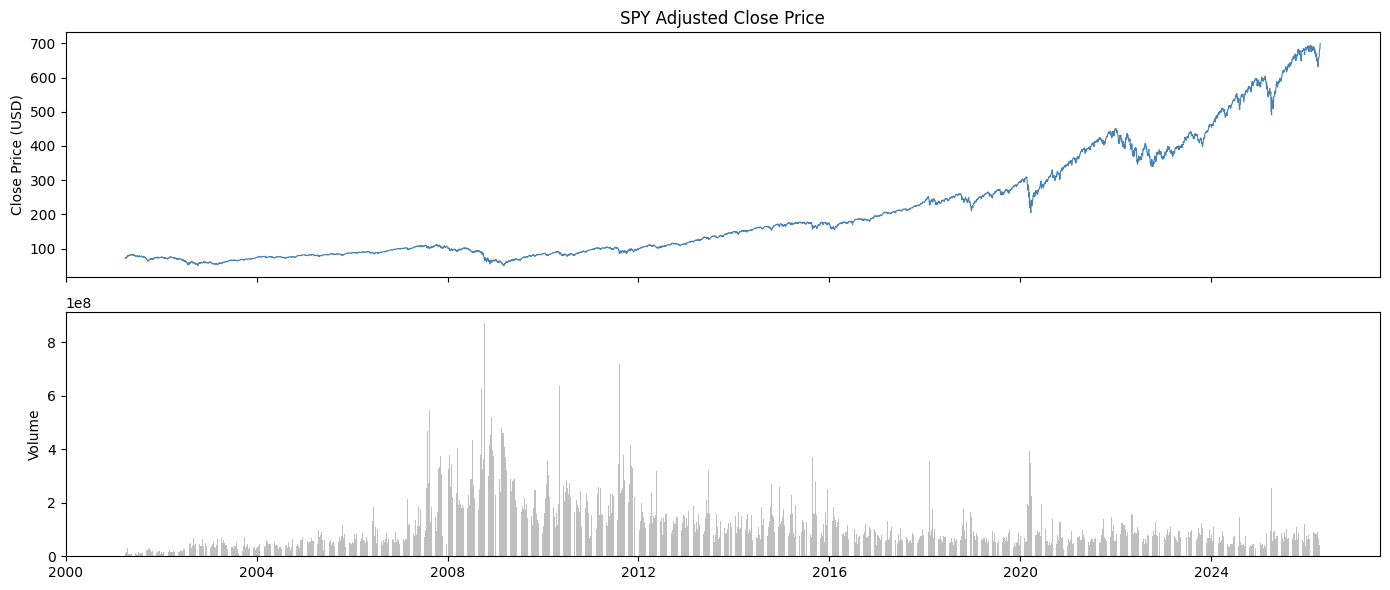

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ohlcv.index, ohlcv["Close"], linewidth=0.8, color="steelblue")
axes[0].set_ylabel("Close Price (USD)")
axes[0].set_title("SPY Adjusted Close Price")
axes[1].bar(ohlcv.index, ohlcv["Volume"], width=1, color="gray", alpha=0.5)
axes[1].set_ylabel("Volume")
plt.tight_layout()
plt.show()

## 2. Load supplementary data


In [4]:
from src.data_loader import load_putcall_ratio, load_aaii_sentiment

pc_ratio = load_putcall_ratio(raw_dir=DATA_RAW)
sentiment = load_aaii_sentiment(raw_dir=DATA_RAW)

if pc_ratio.empty:
    print("⚠ Put/call ratio not found — will proceed without it.")
else:
    print(
        f"Put/call ratio: {len(pc_ratio)} rows, {pc_ratio.index.min().date()} → {pc_ratio.index.max().date()}"
    )

if sentiment.empty:
    print("⚠ AAII sentiment not found — will proceed without it.")
else:
    print(
        f"AAII sentiment: {len(sentiment)} rows, {sentiment.index.min().date()} → {sentiment.index.max().date()}"
    )
    print(sentiment.tail())

04:50:56 | WARNING | src.data_loader | Put/call ratio CSV not found. Download from https://www.cboe.com/us/options/market_statistics/daily/ and save as data/raw/put_call_ratio.csv
04:50:56 | WARNING | src.data_loader | AAII sentiment CSV not found. Download from https://www.aaii.com/sentimentsurvey/sent_results and save as data/raw/aaii_sentiment.csv


⚠ Put/call ratio not found — will proceed without it.
⚠ AAII sentiment not found — will proceed without it.


## 3. Build the merged raw dataset


In [5]:
from src.data_loader import build_raw_dataset

raw_df = build_raw_dataset(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    raw_dir=DATA_RAW,
    processed_dir=DATA_PROCESSED,
)

print(f"\nRaw dataset shape: {raw_df.shape}")
print("Columns:", raw_df.columns.tolist())
print("\nMissing values:")
print(raw_df.isnull().sum()[raw_df.isnull().sum() > 0])
raw_df.tail()

04:50:56 | INFO    | src.data_loader | Loading merged raw dataset from cache: /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/raw_dataset.parquet



Raw dataset shape: (5606, 5)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Missing values:
Series([], dtype: int64)


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-04-09,674.840027,681.159973,673.770020,679.909973,57134400
2026-04-10,681.320007,682.030029,678.450012,679.460022,42253500
2026-04-13,677.409973,686.299988,676.580017,686.099976,54185800
2026-04-14,687.690002,694.580017,687.659973,694.460022,63480500
2026-04-15,695.260010,700.280029,694.200012,699.940002,58138100


## 4. Feature engineering


In [6]:
from src.features import build_features

feat_df = build_features(
    raw_df,
    vol_window=VOL_WINDOW,
    rolling_windows=ROLLING_WINDOWS,
    annualise_target=False,
)

print(f"Feature dataset shape: {feat_df.shape}")
print("Columns:", feat_df.columns.tolist())

04:50:56 | INFO    | src.features | Feature build complete. Rows with NaN: 1 leading (lag), ~20 trailing (forward target).


Feature dataset shape: (5606, 20)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_abs_mean_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_abs_mean_10', 'rolling_mean_21', 'rolling_std_21', 'rolling_abs_mean_21', 'realized_vol_21d']


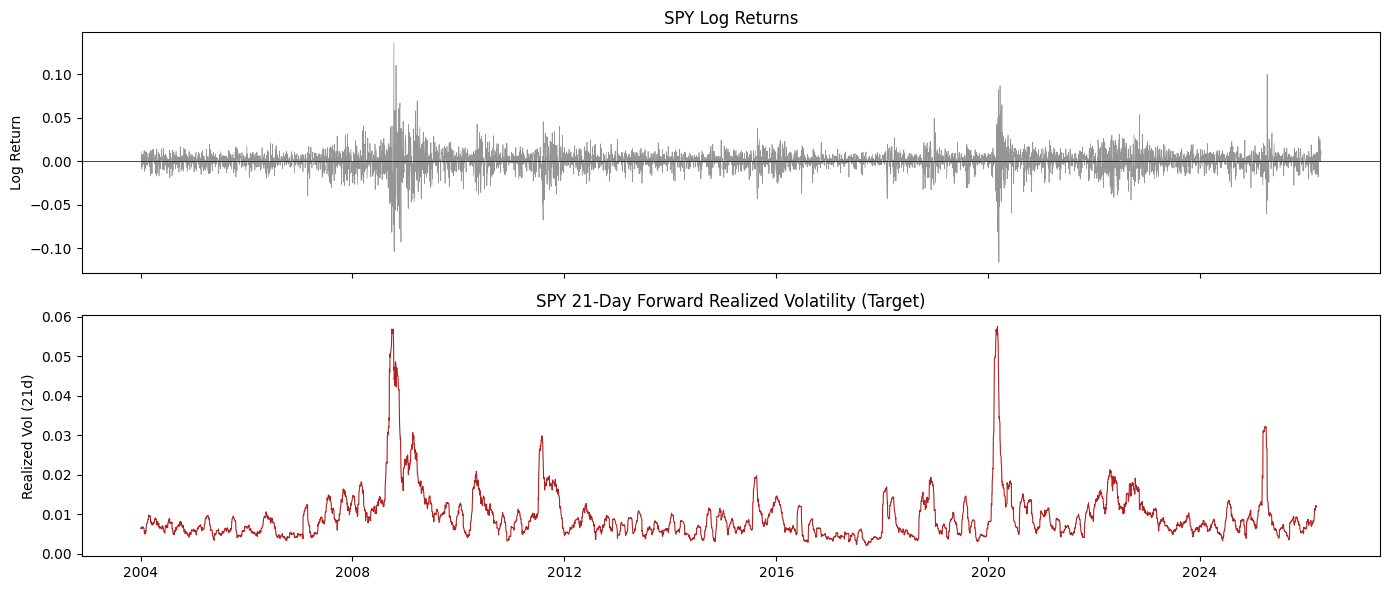

In [7]:
# Quick sanity check: inspect log returns and the target vol
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(
    feat_df.index, feat_df["log_return"], linewidth=0.5, color="dimgray", alpha=0.7
)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Log Return")
axes[0].set_title("SPY Log Returns")

axes[1].plot(
    feat_df.index, feat_df["realized_vol_21d"], linewidth=0.8, color="firebrick"
)
axes[1].set_ylabel("Realized Vol (21d)")
axes[1].set_title("SPY 21-Day Forward Realized Volatility (Target)")
plt.tight_layout()
plt.show()

In [8]:
# Summary statistics of all engineered features
feat_df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,5606.0,2.239453e+02,1.631127e+02,4.969160e+01,9.481310e+01,1.664791e+02,3.115805e+02,6.952600e+02
High,5606.0,2.251799e+02,1.639315e+02,5.119070e+01,9.533380e+01,1.673566e+02,3.135810e+02,7.002800e+02
Low,5606.0,2.226010e+02,1.622129e+02,4.907000e+01,9.397400e+01,1.652285e+02,3.098250e+02,6.942000e+02
Close,5606.0,2.239801e+02,1.631527e+02,4.980860e+01,9.469480e+01,1.665707e+02,3.115388e+02,6.999400e+02
Volume,5606.0,1.190302e+08,8.919273e+07,1.527000e+07,6.243975e+07,8.909105e+07,1.463314e+08,8.710263e+08
log_return,5605.0,4.000000e-04,1.180000e-02,-1.159000e-01,-3.900000e-03,7.000000e-04,5.800000e-03,1.356000e-01
abs_return,5605.0,7.600000e-03,9.100000e-03,0.000000e+00,2.000000e-03,5.000000e-03,1.010000e-02,1.356000e-01
oc_return,5606.0,1.000000e-04,9.200000e-03,-9.420000e-02,-3.600000e-03,6.000000e-04,4.400000e-03,1.060000e-01
intraday_range,5606.0,-4.614400e+00,6.167000e-01,-6.701500e+00,-5.042300e+00,-4.654300e+00,-4.240800e+00,-2.145100e+00


## 5. Chronological train / val / test split


In [9]:
from src.features import time_split
from src.utils import describe_splits

# Drop rows with NaN in target or core features before splitting
target_col = f"realized_vol_{VOL_WINDOW}d"
clean_df = feat_df.dropna(subset=["log_return", target_col])
print(f"Rows before dropping NaN: {len(feat_df):,}")
print(f"Rows after  dropping NaN: {len(clean_df):,}")

train, val, test = time_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)
print()
print(describe_splits(train, val, test))

04:50:56 | INFO    | src.features | Split sizes — Train: 3020, Val: 1006, Test: 1558


Rows before dropping NaN: 5,606
Rows after  dropping NaN: 5,584

                 Start         End  Days
Split                                   
Train       2004-01-05  2015-12-31  3020
Validation  2016-01-04  2019-12-31  1006
Test        2020-01-02  2026-03-16  1558


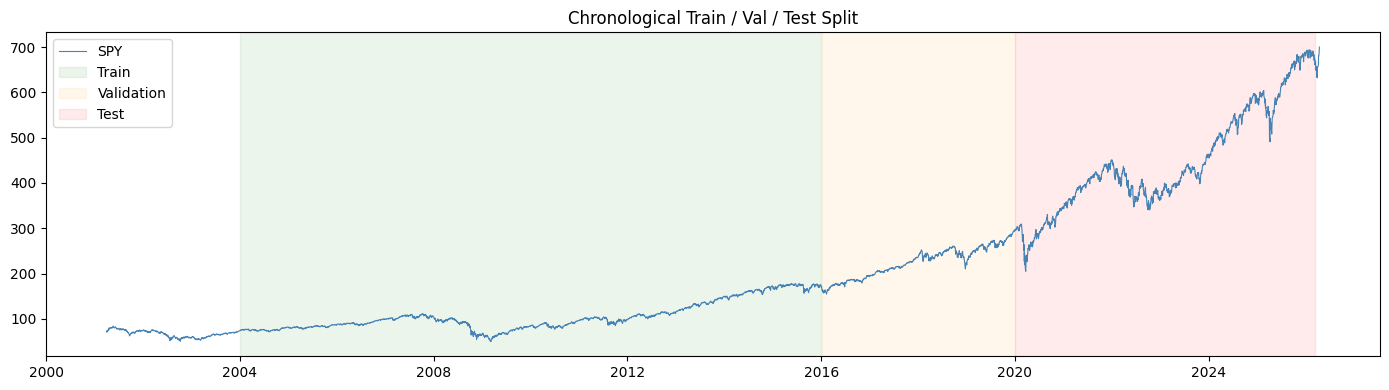

In [10]:
# Visualise the split boundaries on the price chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ohlcv.index, ohlcv["Close"], linewidth=0.8, color="steelblue", label="SPY")
ax.axvspan(
    train.index.min(), train.index.max(), alpha=0.08, color="green", label="Train"
)
ax.axvspan(
    val.index.min(), val.index.max(), alpha=0.08, color="orange", label="Validation"
)
ax.axvspan(test.index.min(), test.index.max(), alpha=0.08, color="red", label="Test")
ax.legend()
ax.set_title("Chronological Train / Val / Test Split")
plt.tight_layout()
plt.show()

## 6. Save processed datasets


In [11]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

clean_df.to_parquet(DATA_PROCESSED / "features_all.parquet")
train.to_parquet(DATA_PROCESSED / "train.parquet")
val.to_parquet(DATA_PROCESSED / "val.parquet")
test.to_parquet(DATA_PROCESSED / "test.parquet")

print("Saved:")
for p in DATA_PROCESSED.glob("*.parquet"):
    print(f"  {p}")

Saved:
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/train.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/test.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/val.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/raw_dataset.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/features_all.parquet


## 7. Feature correlation check


In [12]:
from src.features import drop_correlated_features, variance_inflation_check
from src.utils import plot_correlation_matrix

# All engineered numeric features (exclude raw OHLCV and target)
exclude = ["Open", "High", "Low", "Close", "Volume", target_col]
all_feature_cols = [c for c in clean_df.columns if c not in exclude]

print(f"All feature columns ({len(all_feature_cols)}): {all_feature_cols}")

All feature columns (14): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_abs_mean_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_abs_mean_10', 'rolling_mean_21', 'rolling_std_21', 'rolling_abs_mean_21']


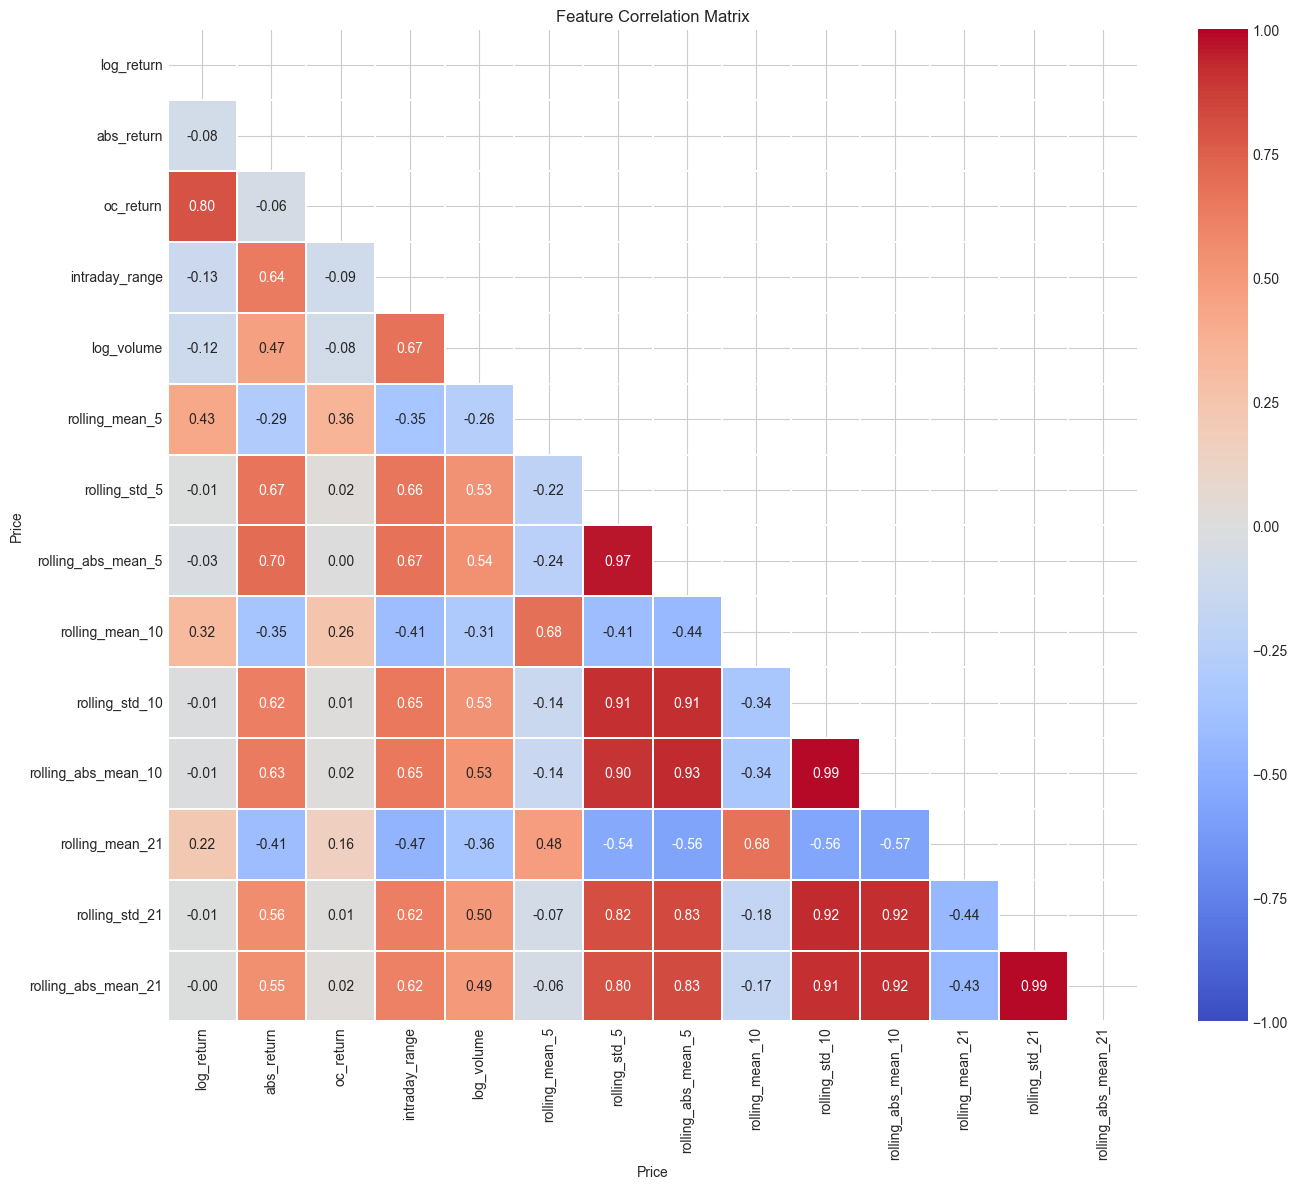

In [13]:
fig = plot_correlation_matrix(clean_df, all_feature_cols)
plt.show()

In [14]:
kept_features = drop_correlated_features(clean_df, all_feature_cols, threshold=0.95)
print(f"Features after correlation pruning ({len(kept_features)}): {kept_features}")

04:50:57 | INFO    | src.features | Dropping correlated features (threshold=0.95): ['rolling_abs_mean_5', 'rolling_abs_mean_10', 'rolling_abs_mean_21']


Features after correlation pruning (11): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21']


In [15]:
vif_df = variance_inflation_check(clean_df, kept_features)
print("VIF scores:")
print(vif_df.to_string(index=False))

04:50:57 | WARNING | src.features | Features with VIF > 10.0 (potential multicollinearity):
       feature        VIF
    log_volume 120.256232
intraday_range  92.142900
rolling_std_10  41.704472
rolling_std_21  25.108298
 rolling_std_5  16.455703


VIF scores:
        feature        VIF
     log_volume 120.256232
 intraday_range  92.142900
 rolling_std_10  41.704472
 rolling_std_21  25.108298
  rolling_std_5  16.455703
     abs_return   3.566955
rolling_mean_10   3.147727
     log_return   2.994583
      oc_return   2.794681
rolling_mean_21   2.564980
 rolling_mean_5   2.292326


## Summary

| Item                   | Value                                |
| ---------------------- | ------------------------------------ |
| Total trading days     | —                                    |
| Features engineered    | —                                    |
| Features after pruning | —                                    |
| Train / Val / Test     | 2005–2015 / 2016–2019 / 2020–present |
| Target                 | 21-day forward realized vol          |

Proceed to `02_eda_normality.ipynb` for distribution analysis and normality testing.
